In [1]:
import sys
import os
from datetime import datetime, timedelta

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data
from src.visualizer import plot_daily_candlestick
from src.features import calculate_atr
from src.risk_manager import evaluate_trade_risk

In [2]:
# Set tanggal dinamis (Contoh: Menarik data dari 6 bulan lalu hingga hari ini)
hari_ini = datetime.now().strftime('%Y-%m-%d')
enam_bulan_lalu = (datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d')

# 1. Panggil data BUMI riil dari Bursa Efek Indonesia (.JK)
# Data ini mencerminkan kondisi pasar riil per Juni 2026
df_bumi = load_stock_data(ticker="BUMI.JK", start_date=enam_bulan_lalu, end_date=hari_ini)
# ------------------------------------------

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 114 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 4 baris data (NaN atau Volume 0).
Berhasil memuat 110 baris data bersih untuk BUMI.JK.


In [3]:
print(df_bumi)

             Open   High    Low  Close       Volume
Date                                               
2025-12-22  348.0  394.0  346.0  394.0  12257775400
2025-12-23  402.0  406.0  376.0  380.0   8335353200
2025-12-24  382.0  384.0  360.0  362.0   4795205000
2025-12-29  362.0  376.0  354.0  366.0   5492663300
2025-12-30  370.0  372.0  362.0  366.0   2812869800
...           ...    ...    ...    ...          ...
2026-06-12  144.0  162.0  143.0  157.0   6630659700
2026-06-15  165.0  191.0  163.0  173.0  13335601700
2026-06-17  175.0  178.0  165.0  168.0   4078182600
2026-06-18  169.0  173.0  163.0  171.0   2760389100
2026-06-19  172.0  177.0  167.0  168.0   2642490700

[110 rows x 5 columns]


Menghasilkan grafik candlestick untuk BUMI...


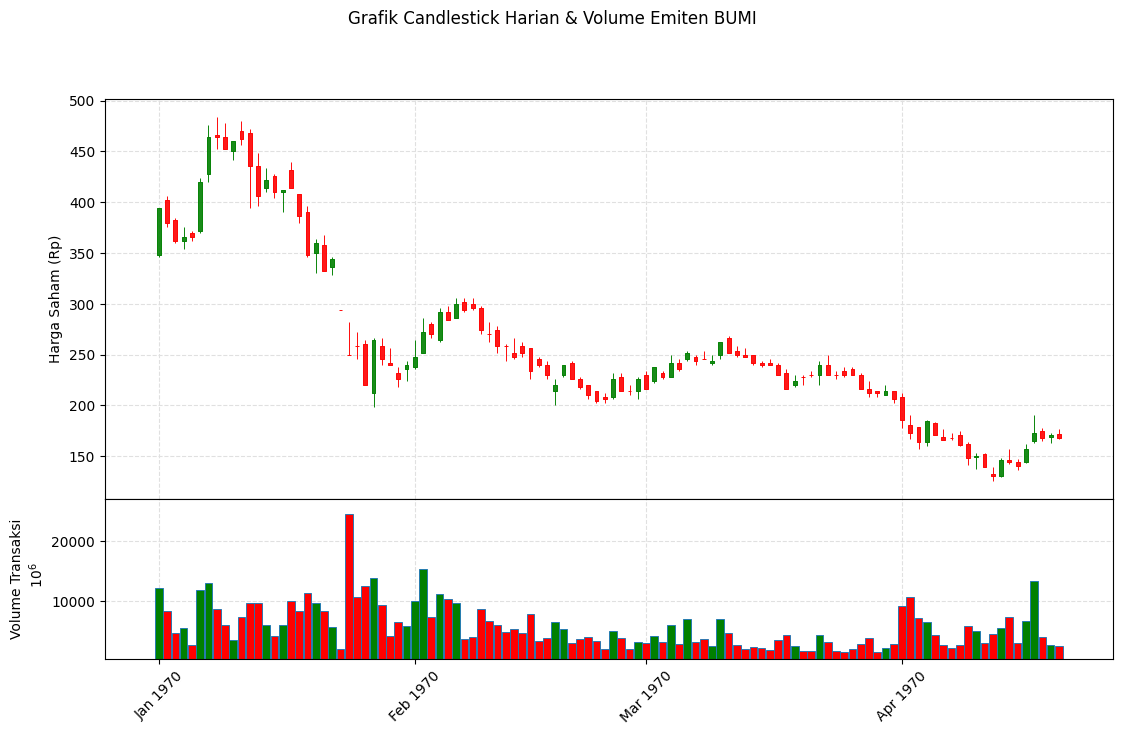

In [4]:
plot_daily_candlestick(df=df_bumi, ticker_name="BUMI")

In [5]:
df_bumi = calculate_atr(df_bumi)
latest_data = df_bumi.iloc[-1]
current_close = float(latest_data['Close'])
current_atr = float(latest_data['ATR'])

resisten_terdekat = 186.0  

trade_analysis = evaluate_trade_risk(
    entry_price=current_close,
    atr=current_atr,
    resistance_level=resisten_terdekat,
    min_rr_ratio=2.0
)

# Cetak Hasil Validasi Hitam-di-Atas-Putih
print("=== LIVE SYSTEM RISK EVALUATION ===")
print(f"Harga Masuk Terkini     : Rp{trade_analysis['entry_price']}")
print(f"Nilai Volatilitas (ATR) : Rp{round(current_atr, 2)}")
print(f"Garis Aman Cut Loss (SL): Rp{trade_analysis['suggested_stop_loss']} (Terproteksi dari noise)")
print(f"Target Resisten (TP)    : Rp{trade_analysis['target_profit_resistance']}")
print(f"Rasio R-to-R Aktual     : {trade_analysis['actual_rr_ratio']}x")
print("-----------------------------------")

if trade_analysis['execute_trade']:
    print("KEPUTUSAN SISTEM: ISI ORDER BELI! Matematika risiko mendukung penuh.")
else:
    print("KEPUTUSAN SISTEM: BLOKIR TRANSAKSI! Jarak ke resisten terlalu sempit, batalkan emosi Anda.")

=== LIVE SYSTEM RISK EVALUATION ===
Harga Masuk Terkini     : Rp168.0
Nilai Volatilitas (ATR) : Rp15.86
Garis Aman Cut Loss (SL): Rp144.21 (Terproteksi dari noise)
Target Resisten (TP)    : Rp186.0
Rasio R-to-R Aktual     : 0.76x
-----------------------------------
KEPUTUSAN SISTEM: BLOKIR TRANSAKSI! Jarak ke resisten terlalu sempit, batalkan emosi Anda.
